In [ ]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

In [ ]:
%%capture
path_count = '/ix1/ylee/Yifan_Zhang/CellRanger_tests/E4S_cxcr4/outs/'
path = path_count


In [ ]:

mdata = mu.read_10x_h5(
    path+'filtered_feature_bc_matrix.h5', 
)

# for cellranger count outputs 
mdata_raw = mu.read_10x_h5(
    path+'raw_feature_bc_matrix.h5', 
)

In [ ]:
path_multi = '/ix1/ylee/Yifan_Zhang/CellRanger_tests/E4S_multi/outs/per_sample_outs/E4S_multi/count/sample_'
# for cellranger multi outputs 
# mdata_raw = mu.read_10x_h5(
#     '/ix1/ylee/Yifan_Zhang/CellRanger_tests/E4S_multi/outs/multi/count/'+'raw_feature_bc_matrix.h5', 
# )


In [ ]:
mdata_raw.var_names_make_unique()
mdata.var_names_make_unique()
mdata

MuData object with n_obs × n_vars = 6764 × 33889
  var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
  2 modalities
    rna:	6764 x 33696
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    prot:	6764 x 193
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [ ]:
mdata_raw

MuData object with n_obs × n_vars = 1332123 × 33889
  var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
  2 modalities
    rna:	1332123 x 33696
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    prot:	1332123 x 193
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [ ]:
# filtered_prot = mdata_raw['prot'][:, mdata_raw['prot'].var_names.str.startswith('sbc')]
# mdata_raw.mod['prot'] = filtered_prot
# filtered_prot = mdata['prot'][:, mdata['prot'].var_names.str.startswith('sbc')]
# mdata.mod['prot'] = filtered_prot

In [ ]:
sbc_rna = mdata['rna'][:, mdata['rna'].var_names.str.startswith('Sgbc')]
sbc_rna.var_names

Index([], dtype='object')

In [ ]:
mdata['rna'].var_names

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'A930006A01Rik',
       ...
       'Gm16367', 'ENSMUSG00000094172', 'ENSMUSG00000094887',
       'ENSMUSG00000091585', 'ENSMUSG00000095763', 'ENSMUSG00000095523',
       'ENSMUSG00000095475', 'ENSMUSG00000094855', 'ENSMUSG00000095019',
       'ENSMUSG00000095041'],
      dtype='object', length=33696)

In [ ]:
mdata_raw['prot'].var_names

Index(['sbc1', 'sbc2', 'sbc3', 'sbc4', 'sbc5', 'sbc6', 'sbc7', 'sbc8', 'sbc9',
       'sbc10',
       ...
       'sbc184', 'sbc185', 'sbc186', 'sbc187', 'sbc188', 'sbc189', 'sbc190',
       'sbc191', 'sbc192', 'CXCR4'],
      dtype='object', length=193)

In [ ]:
mdata_raw['rna'].obs["log10umi"] = np.array(np.log10(mdata_raw['rna'].X.sum(axis=1) + 1)).reshape(-1)

In [ ]:
gene_cxcr4 = mdata['rna'][:, 'Cxcr4']
ADT_cxcr4 = mdata['prot'][:, 'CXCR4']

Pearson  r = 0.2017, p = 4.84e-63
Spearman r = 0.2197, p = 9.41e-75


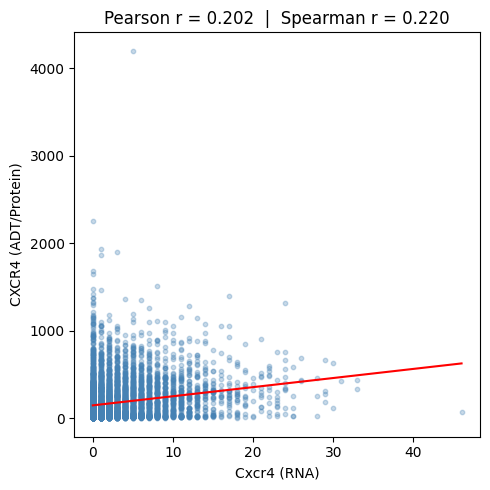

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Extract expression values
gene_cxcr4 = mdata['rna'][:, 'Cxcr4'].X
ADT_cxcr4 = mdata['prot'][:, 'CXCR4'].X

# Convert sparse matrix to array if needed
if hasattr(gene_cxcr4, 'toarray'):
    gene_cxcr4 = gene_cxcr4.toarray().flatten()
else:
    gene_cxcr4 = np.array(gene_cxcr4).flatten()

if hasattr(ADT_cxcr4, 'toarray'):
    ADT_cxcr4 = ADT_cxcr4.toarray().flatten()
else:
    ADT_cxcr4 = np.array(ADT_cxcr4).flatten()

# Correlation statistics
pearson_r, pearson_p = stats.pearsonr(gene_cxcr4, ADT_cxcr4)
spearman_r, spearman_p = stats.spearmanr(gene_cxcr4, ADT_cxcr4)

print(f"Pearson  r = {pearson_r:.4f}, p = {pearson_p:.2e}")
print(f"Spearman r = {spearman_r:.4f}, p = {spearman_p:.2e}")

# Scatter plot with regression line
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(gene_cxcr4, ADT_cxcr4, alpha=0.3, s=10, color='steelblue')

# Regression line
m, b = np.polyfit(gene_cxcr4, ADT_cxcr4, 1)
x_line = np.linspace(gene_cxcr4.min(), gene_cxcr4.max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5)

ax.set_xlabel('Cxcr4 (RNA)')
ax.set_ylabel('CXCR4 (ADT/Protein)')
ax.set_title(f'Pearson r = {pearson_r:.3f}  |  Spearman r = {spearman_r:.3f}')

plt.tight_layout()
plt.show()

In [ ]:
prot = mdata.mod['prot']
prot_DF = prot.to_df()
prot_DF.head()

,sbc1,sbc2,sbc3,sbc4,sbc5,sbc6,sbc7,sbc8,sbc9,sbc10,...,sbc184,sbc185,sbc186,sbc187,sbc188,sbc189,sbc190,sbc191,sbc192,CXCR4
AAACCAAAGTATGACT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2.0,4.0,5.0,7.0,5.0,3.0,2.0,0.0,927.0
AAACCATTCCAGAGAG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,3.0,3.0,1.0,6.0,0.0,44.0
AAACCATTCCTCACAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,6.0,11.0,5.0,5.0,9.0,5.0,7.0,1.0,43.0
AAACCATTCCTCATGT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0
AAACCATTCGATGCGT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,5.0,1.0,2.0,4.0,2.0,0.0,0.0,61.0


In [ ]:
prot_DF['CXCR4']

AAACCAAAGTATGACT-1    927.0
AAACCATTCCAGAGAG-1     44.0
AAACCATTCCTCACAT-1     43.0
AAACCATTCCTCATGT-1     32.0
AAACCATTCGATGCGT-1     61.0
                      ...  
TGTGGTTGTTCCCTGT-1     54.0
TGTGTACGTAACTCCG-1     34.0
TGTGTTAGTAATCGCT-1     63.0
TGTGTTAGTAGCGCCT-1     16.0
TGTGTTAGTCTAATTG-1     49.0
Name: CXCR4, Length: 6764, dtype: float32

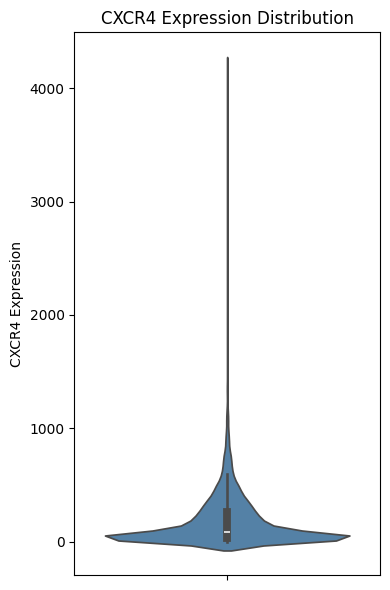

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(4, 6))

sns.violinplot(y=prot_DF['CXCR4'], ax=ax, inner='box', color='steelblue')

ax.set_title('CXCR4 Expression Distribution')
ax.set_ylabel('CXCR4 Expression')
ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
from muon import prot as pt

In [ ]:
# prot.layers['counts'] = prot.X
# pt.pp.dsb(
#     mdata, 
#     mdata_raw, 
#     # empty_counts_range=(1.5, 2.8), 
#     isotype_controls=isotypes, 
#     random_state=1
# )

In [ ]:
prot_DF = mdata['prot'].to_df()
rows = [f'sbc{i}' for i in range(48, 96)]
cols = [f'sbc{i}' for i in range(144, 192)]

cols_to_keep = [c for c in prot_DF.columns if c in rows or c in cols]
prot_DF_filtered = prot_DF[cols_to_keep]
prot_DF_filtered.head()


,sbc48,sbc49,sbc50,sbc51,sbc52,sbc53,sbc54,sbc55,sbc56,sbc57,...,sbc182,sbc183,sbc184,sbc185,sbc186,sbc187,sbc188,sbc189,sbc190,sbc191
AAACCAAAGTATGACT-1,0.0,1.0,4.0,3.0,1.0,4.0,9.0,6.0,2.0,1.0,...,3.0,3.0,1.0,2.0,4.0,5.0,7.0,5.0,3.0,2.0
AAACCATTCCAGAGAG-1,0.0,3.0,0.0,2.0,0.0,1.0,4.0,0.0,2.0,3.0,...,1.0,1.0,1.0,0.0,0.0,0.0,3.0,3.0,1.0,6.0
AAACCATTCCTCACAT-1,0.0,8.0,3.0,8.0,3.0,6.0,10.0,5.0,2.0,4.0,...,2.0,11.0,5.0,6.0,11.0,5.0,5.0,9.0,5.0,7.0
AAACCATTCCTCATGT-1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCATTCGATGCGT-1,0.0,1.0,1.0,2.0,2.0,3.0,4.0,0.0,2.0,3.0,...,2.0,0.0,1.0,1.0,5.0,1.0,2.0,4.0,2.0,0.0


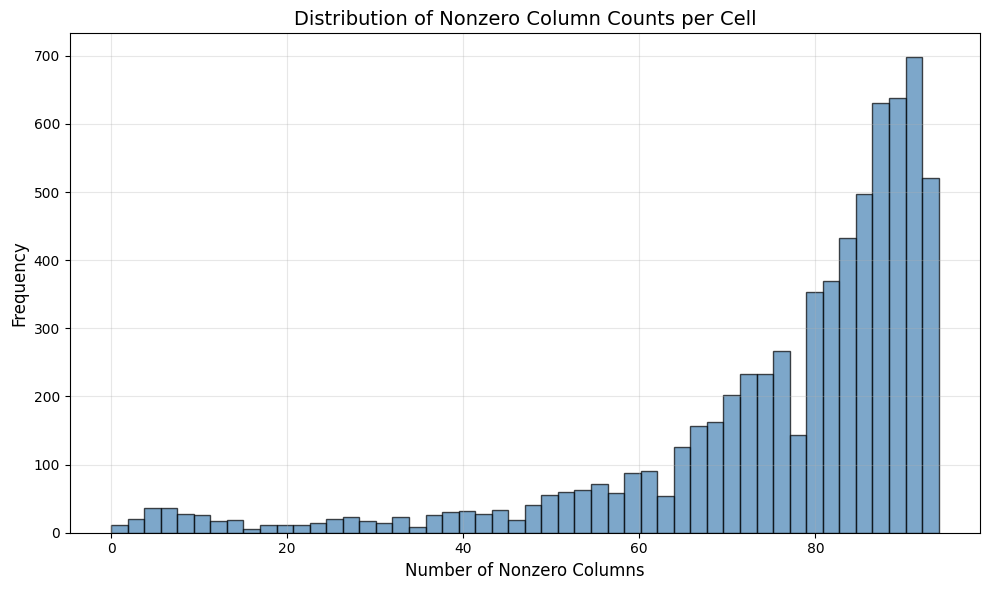

Summary Statistics for Nonzero Column Counts:
Mean: 76.36
Median: 83.00
Std Dev: 18.92
Min: 0
Max: 94


In [ ]:
# Count nonzero columns per row
nonzero_col_counts = (prot_DF_filtered != 0).sum(axis=1)

# Plot distribution
plt.figure(figsize=(10, 6), dpi=100)
plt.hist(nonzero_col_counts, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Number of Nonzero Columns', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Nonzero Column Counts per Cell', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Summary Statistics for Nonzero Column Counts:")
print(f"Mean: {nonzero_col_counts.mean():.2f}")
print(f"Median: {nonzero_col_counts.median():.2f}")
print(f"Std Dev: {nonzero_col_counts.std():.2f}")
print(f"Min: {nonzero_col_counts.min()}")
print(f"Max: {nonzero_col_counts.max()}")

In [ ]:
prot_DF_filtered.to_csv('raw_BCs.csv')

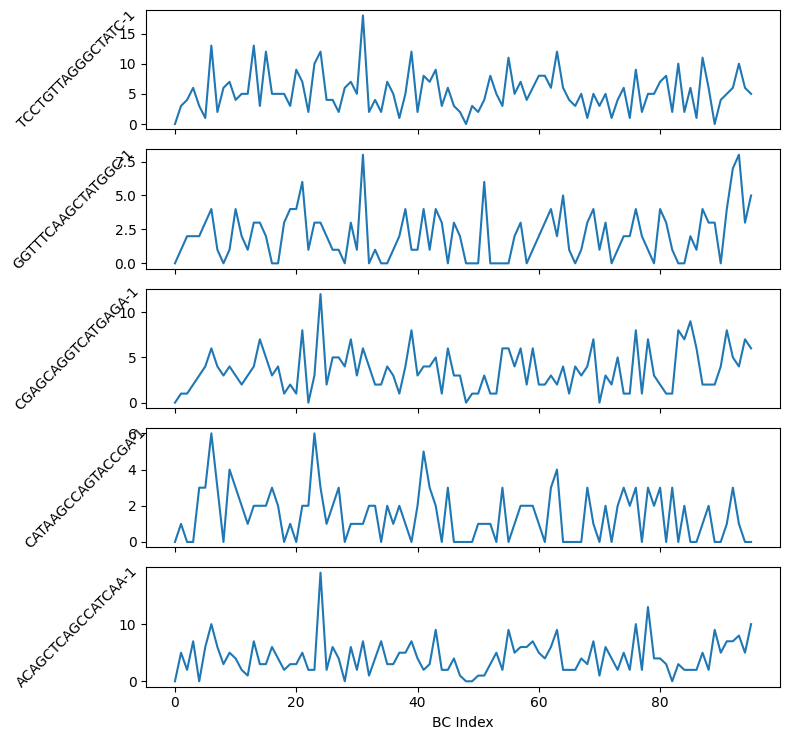

In [ ]:
import matplotlib.pyplot as plt

k = 5 # number of rows to sample
sampled = prot_DF_filtered.sample(n=k, replace=False)

fig, axes = plt.subplots(
    nrows=k,
    ncols=1,
    figsize=(8, 1.5 * k),  # reduced height per subplot
    sharex=True
)

# If k == 1, axes is not a list
if k == 1:
    axes = [axes]

for ax, (idx, row) in zip(axes, sampled.iterrows()):
    ax.plot(row.values)
    ax.set_ylabel(str(idx), rotation=45, labelpad=30, va="center")

axes[-1].set_xlabel("BC Index")
plt.tight_layout()
plt.savefig('BC.png')
plt.show()


## load BC from gene

In [ ]:
adata = sc.read_10x_h5(path+'filtered_feature_bc_matrix.h5', gex_only=False)
adata.var_names_make_unique()
adata.var.loc[adata.var.gene_ids.str.startswith('sgbc'), "feature_types"] = "Spatial Capture"

sbcs = adata.var_names[adata.var_names.str.contains('sbc')]

In [ ]:
adata = sc.read_10x_h5(path+'filtered_feature_bc_matrix.h5', gex_only=False)
adata_temp = adata

In [ ]:
adata_temp.var

,gene_ids,feature_types,genome,pattern,read,sequence
Xkr4,ENSMUSG00000051951,Gene Expression,GRCm39,,,
Gm1992,ENSMUSG00000089699,Gene Expression,GRCm39,,,
Gm19938,ENSMUSG00000102331,Gene Expression,GRCm39,,,
Gm37381,ENSMUSG00000102343,Gene Expression,GRCm39,,,
Rp1,ENSMUSG00000025900,Gene Expression,GRCm39,,,
...,...,...,...,...,...,...
sbc189,sgbc-tsb-v2-189,Antibody Capture,,5P(BC),R2,GCACTAGTACGCCGC
sbc190,sgbc-tsb-v2-190,Antibody Capture,,5P(BC),R2,AGGGCGCCCTAATAA
sbc191,sgbc-tsb-v2-191,Antibody Capture,,5P(BC),R2,TTACCACACGAACGA
sbc192,sgbc-tsb-v2-192,Antibody Capture,,5P(BC),R2,GATAGATGATCCTTA


In [ ]:
rows = [f'sbc{i}' for i in range(48, 96)]
cols = [f'sbc{i}' for i in range(144, 192)]
df = pd.DataFrame(index=rows, columns=cols)
for r in rows:
    for c in cols:
        df.loc[r, c] = f'{r}-{c}'

x = []
y = []

### Search with only 2 BCs

In [ ]:
df_X = adata.to_df()[df.index]
nonzero_counts = (df_X != 0).sum(axis=1)
xBC_counts = nonzero_counts.clip(upper=2).tolist()

df_Y = adata.to_df()[df.columns]
nonzero_counts = (df_Y != 0).sum(axis=1)
yBC_counts = nonzero_counts.clip(upper=2).tolist()

error_thres = 10
singleBC_idx = []
print_error_X = 0
print_error_Y = 0
oligo_error_X = 0
oligo_error_Y = 0

for i in range(len(xBC_counts)):
    if xBC_counts[i] == 2:
        nz_idx = np.where(df_X.iloc[i,:].to_numpy() != 0)[0]
        if nz_idx.max() - nz_idx.min() < error_thres:
            print_error_X += 1
        else:
            oligo_error_X += 1
        
    if yBC_counts[i] == 2:
        nz_idy = np.where(df_Y.iloc[i,:].to_numpy() != 0)[0]
        if nz_idy.max() - nz_idy.min() < error_thres:
            print_error_Y += 1
        else:
            oligo_error_Y += 1
    
    if xBC_counts[i] == 1 and yBC_counts[i] == 1:
        singleBC_idx.append(i)
        
count_nonzero = sum(x != 0 for x in singleBC_idx)
print(str(count_nonzero) + 'in' + str(len(xBC_counts))) 
print('adjacent error X ' + str(print_error_X))
print(oligo_error_X)
print('adjacent error Y ' + str(print_error_Y))
print(oligo_error_Y)

3in6764
adjacent error X 16
6711
adjacent error Y 9
6716


In [ ]:
top10 = df_X.replace(0, np.nan)

## Select top

In [ ]:
df_adata = adata.to_df()[df.index]

topK = 20

top10 = df_adata.replace(0, np.nan).apply(lambda row: row.nlargest(topK).dropna().index.tolist(), axis=1)

x = [
    np.random.choice(choices) if len(choices) >= 1 else None
    for choices in top10
]

df_adata = adata.to_df()[df.columns]
top10 = df_adata.replace(0, np.nan).apply(lambda row: row.nlargest(topK).dropna().index.tolist(), axis=1)

y = [
    np.random.choice(choices) if len(choices) >= 1 else None
    for choices in top10
]

len(x), len(y)

(6764, 6764)

In [ ]:
xy_raw = pd.DataFrame({'x': x, 'y': y})
xy_raw

,x,y
0,sbc63,sbc174
1,sbc61,sbc174
2,sbc77,sbc164
3,sbc51,sbc145
4,sbc52,sbc157
...,...,...
6759,sbc55,sbc175
6760,sbc69,sbc155
6761,sbc61,sbc155
6762,sbc59,sbc155


In [ ]:
import matplotlib.pyplot as plt

# Categorize each row
def categorize(row):
    x_missing = pd.isna(row['x'])
    y_missing = pd.isna(row['y'])
    if not x_missing and not y_missing:
        return "both"
    elif x_missing and not y_missing:
        return "only y"
    elif not x_missing and y_missing:
        return "only x"
    else:
        return "neither"

category_counts = xy_raw.apply(categorize, axis=1).value_counts().reindex(["only x", "only y", "both", "neither"], fill_value=0)

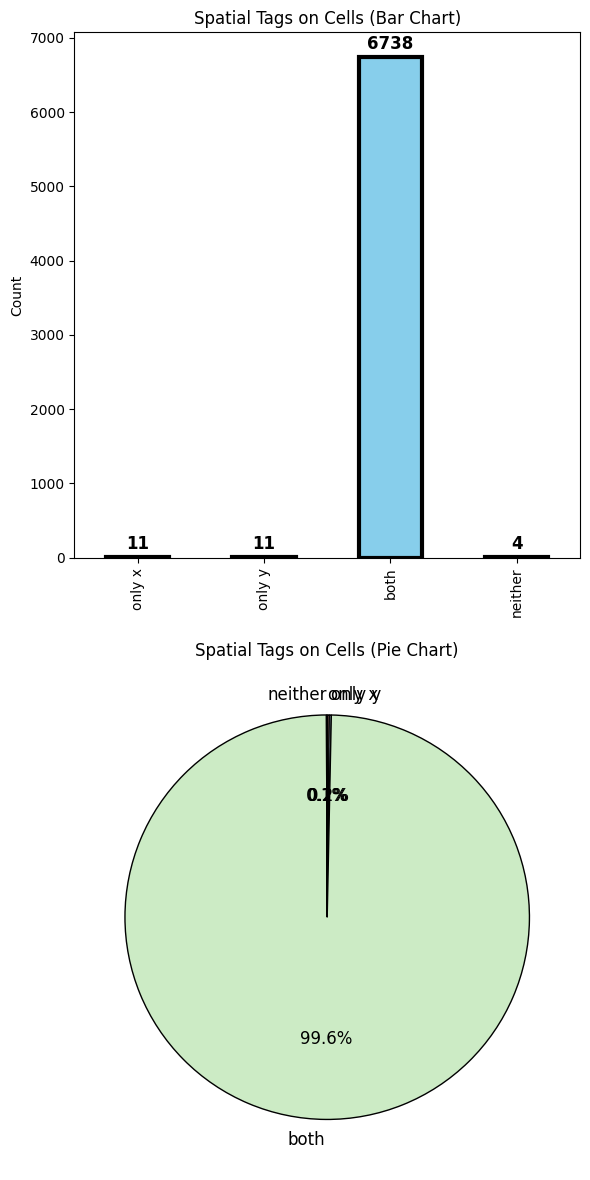

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(6, 12), dpi=100)

# Bar chart (original)
bars = category_counts.plot(kind="bar", linewidth=3, edgecolor='black', ax=axes[0], color='skyblue')
axes[0].set_ylabel("Count")
axes[0].set_title("Spatial Tags on Cells (Bar Chart)")

# Add cell number (count) on each bar
for p in axes[0].patches:
    count = int(p.get_height())
    axes[0].annotate(str(count), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold', xytext=(0, 3), textcoords='offset points')

# Pie chart with annotation
labels = category_counts.index.tolist()
sizes = category_counts.values
colors = plt.cm.Pastel1(range(len(sizes)))
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, autopct='%1.1f%%',
    startangle=90, counterclock=False, colors=colors, wedgeprops=dict(edgecolor='black')
)
for text in texts + autotexts:
    text.set_fontsize(12)
axes[1].set_title("Spatial Tags on Cells (Pie Chart)")

plt.tight_layout()
plt.show()

In [ ]:
# def impute_missing_xy(df):
#     """
#     Impute missing x or y in each row, only if exactly one is missing,
#     by filling the missing value with the most likely pairing
#     based on the observed (x, y) pairs in the rest of the dataframe.
#     If there are ties for the most likely pairing, randomly pick one.
#     """
#     from collections import Counter
#     import numpy as np

#     # Calculate co-occurrence frequencies
#     # Only count rows where both x and y are present (neither missing)
#     cooc_counts = df.dropna().value_counts()

#     # Marginals for x and y
#     x_given_y = {}
#     y_given_x = {}
#     # Create mappings to find the most likely y for each x, and vice versa
#     for (row_x, row_y), count in cooc_counts.items():
#         if row_x not in y_given_x:
#             y_given_x[row_x] = Counter()
#         if row_y not in x_given_y:
#             x_given_y[row_y] = Counter()
#         y_given_x[row_x][row_y] += count
#         x_given_y[row_y][row_x] += count

#     # Helper to get the most likely pair, with random tie breaking
#     def most_likely(mapping, key):
#         # mapping: dict of key -> Counter of possible matches
#         if key in mapping and mapping[key]:
#             counter = mapping[key]
#             if not counter:
#                 return None
#             max_count = max(counter.values())
#             candidates = [val for val, cnt in counter.items() if cnt == max_count]
#             if len(candidates) == 1:
#                 return candidates[0]
#             else:
#                 return np.random.choice(candidates)
#         return None

#     df_imputed = df.copy()
#     for idx, row in df.iterrows():
#         # Only impute if exactly one of x or y is missing
#         x_missing = pd.isna(row['x'])
#         y_missing = pd.isna(row['y'])
#         if x_missing and not y_missing:
#             imputed_x = most_likely(x_given_y, row['y'])
#             df_imputed.at[idx, 'x'] = imputed_x
#         elif y_missing and not x_missing:
#             imputed_y = most_likely(y_given_x, row['x'])
#             df_imputed.at[idx, 'y'] = imputed_y
#         # If both missing or neither missing, do nothing
#     return df_imputed

# # Example usage:
# xy_imputed = impute_missing_xy(xy_raw)
# xy_imputed

In [ ]:
# heatmap_data = xy_imputed.value_counts().reset_index(
#     name='count').pivot(index='x', columns='y', values='count').fillna(0)
# heatmap_data = heatmap_data.reindex(df.index).T.reindex(df.columns).T.fillna(0).T

# plt.figure(figsize=(10, 10), dpi=300)
# sns.heatmap(
#     np.log10(heatmap_data+1),
#     annot=False,
#     fmt='.1f',
#     cmap='plasma',
#     square=True,
#     cbar=False,
#     annot_kws={"size":5},
#     xticklabels=1,
#     yticklabels=1
# )
# plt.xticks(fontsize=5)
# plt.yticks(fontsize=5)
# plt.xlabel('Plate 1', fontsize=5)
# plt.ylabel('Plate 2', fontsize=5)
# plt.show()

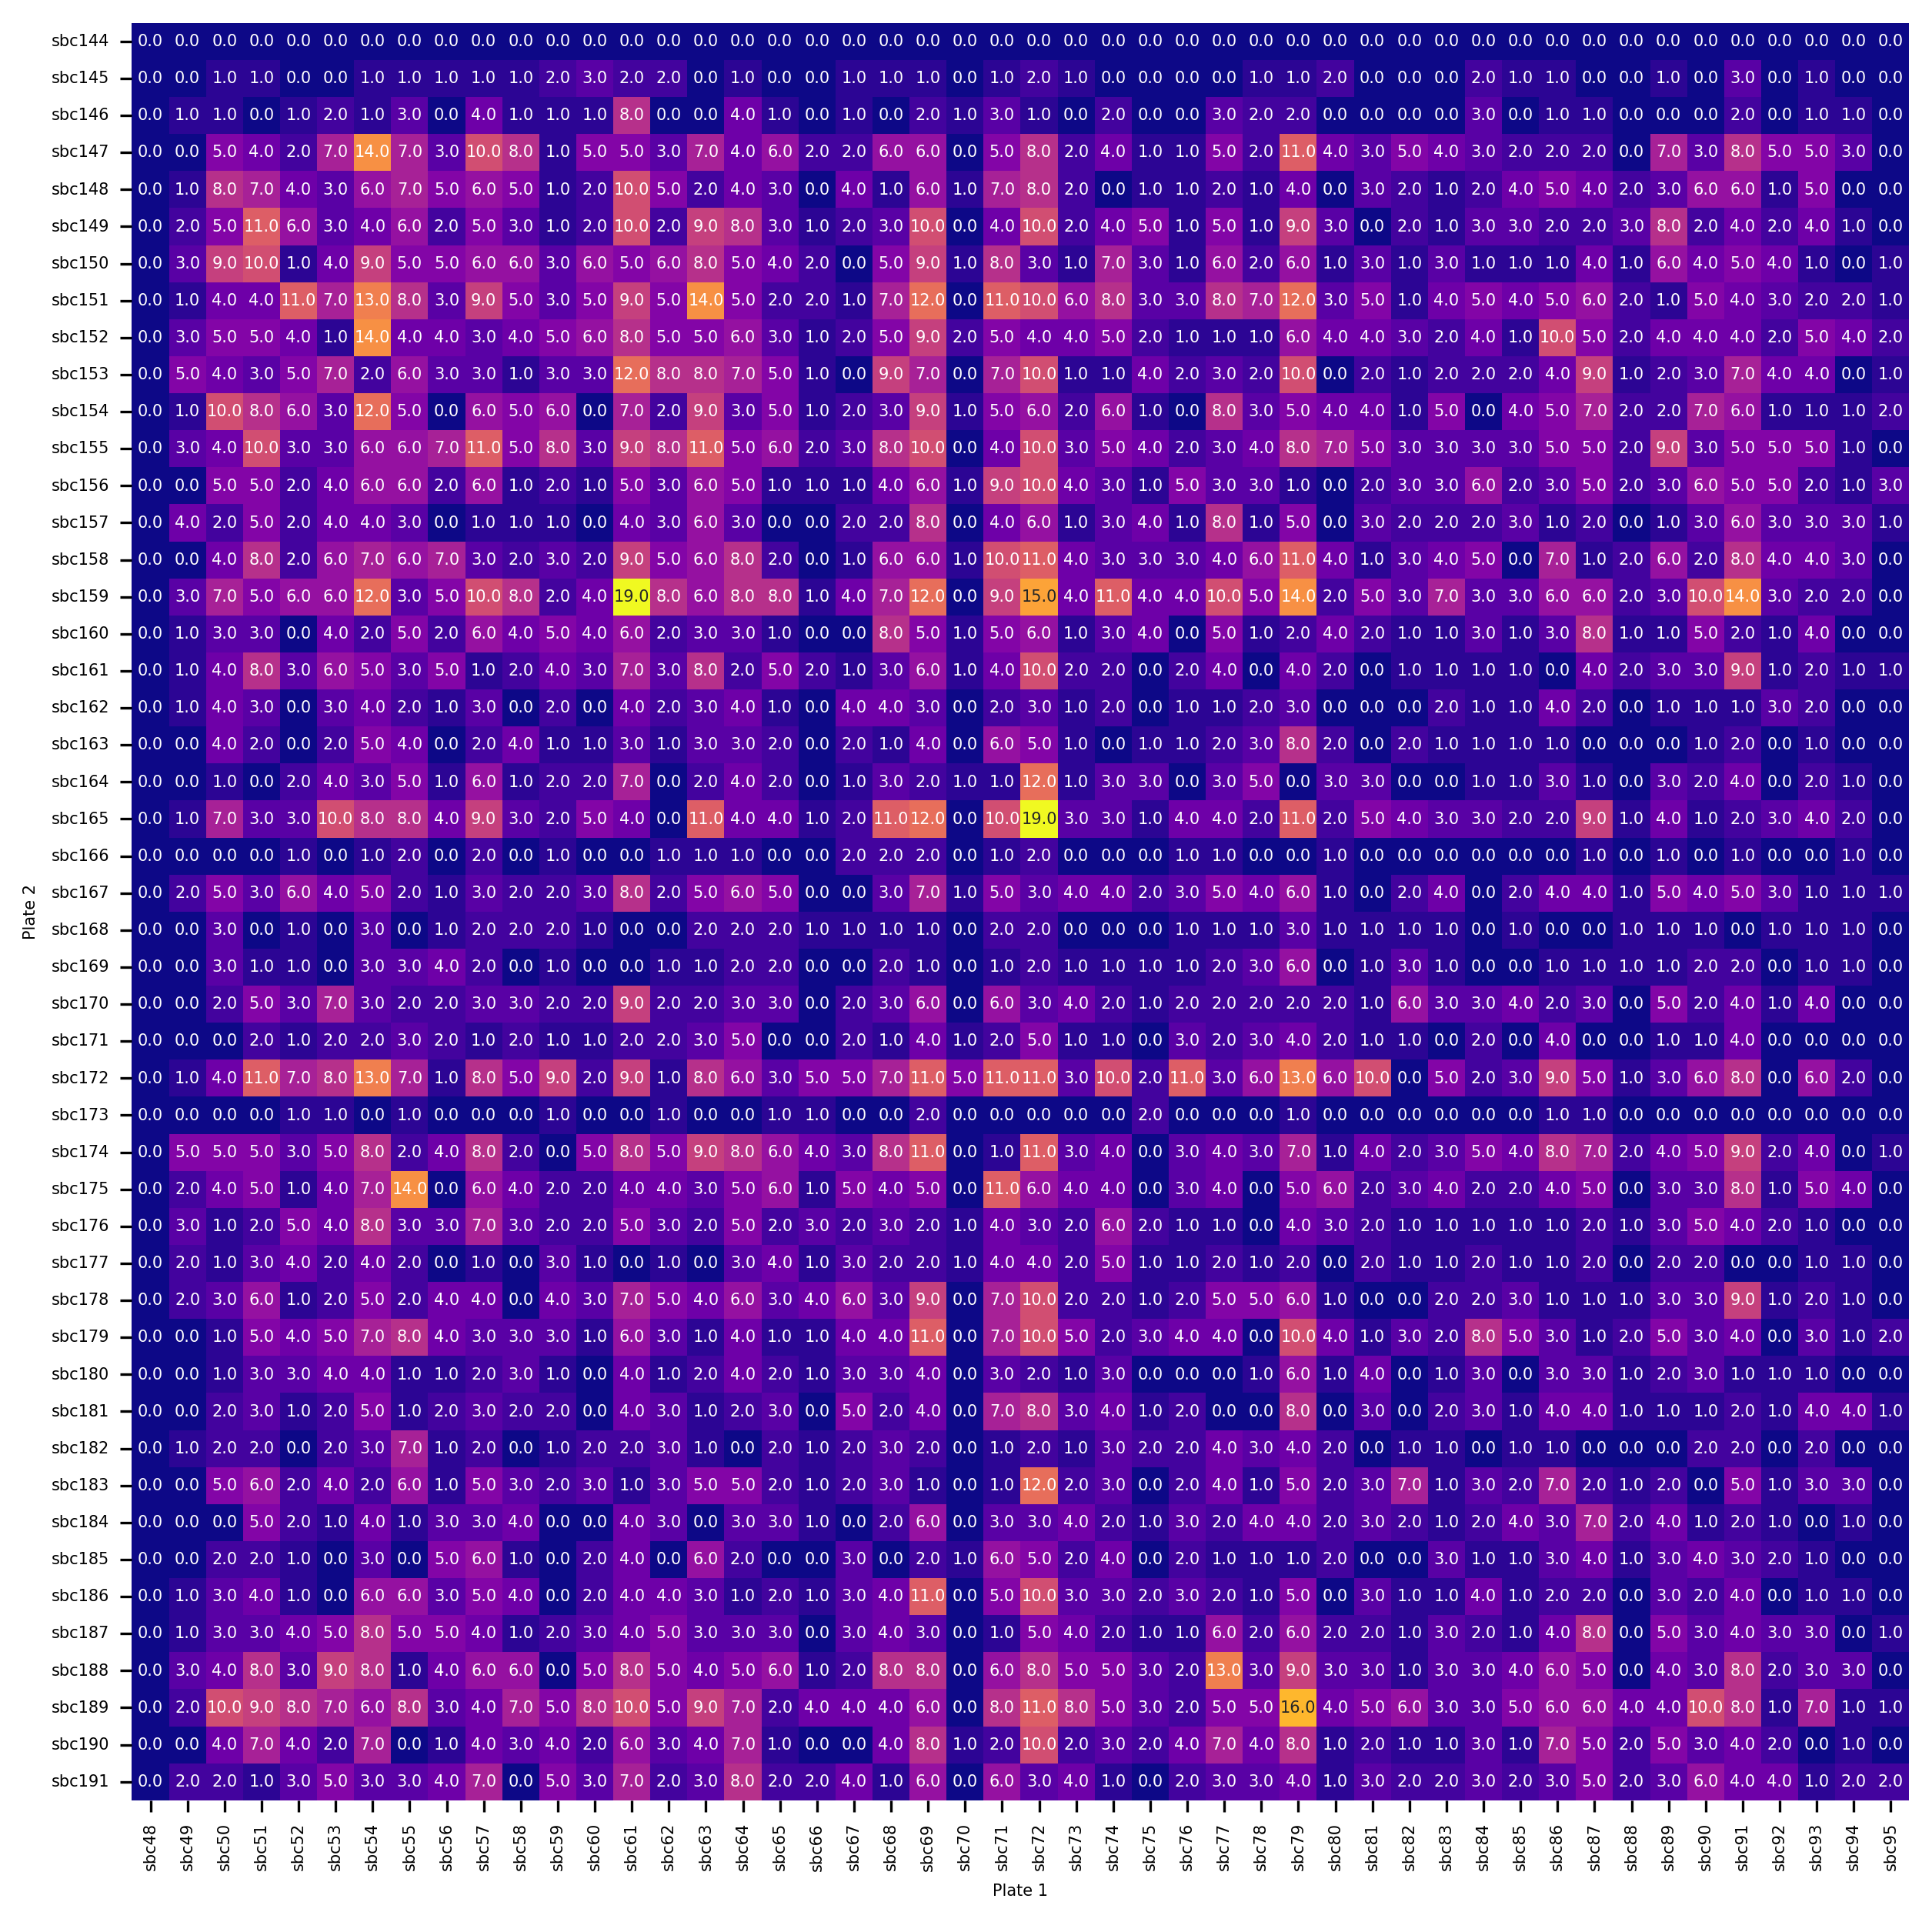

In [ ]:
heatmap_data = xy_raw.value_counts().reset_index(
    name='count').pivot(index='x', columns='y', values='count').fillna(0)
heatmap_data = heatmap_data.reindex(df.index).T.reindex(df.columns).T.fillna(0).T

plt.figure(figsize=(10, 10), dpi=300)
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='plasma',
    square=True,
    cbar=False,
    annot_kws={"size":5},
    xticklabels=1,
    yticklabels=1
)
plt.xticks(fontsize=5)
plt.yticks(fontsize=5)
plt.xlabel('Plate 1', fontsize=5)
plt.ylabel('Plate 2', fontsize=5)
plt.savefig('/tmp/heatmap_raw.png', dpi=300)
plt.show()